## Data Ingestion

In [1]:
import pandas as pd
from sqlalchemy import create_engine
from urllib.parse import quote_plus

password = "Vin@1595"
encoded_password = quote_plus(password)

In [2]:
data_path = 'C:/Users/Asus/Desktop/Vineet Data/Project/House Price Prediction/Bengaluru_House_Data.csv'
df = pd.read_csv(data_path)
df

,area_type,availability,location,size,society,total_sqft,bath,balcony,price
0,Super built-up Area,19-Dec,Electronic City Phase II,2 BHK,Coomee,1056,2.0,1.0,39.07
1,Plot Area,Ready To Move,Chikka Tirupathi,4 Bedroom,Theanmp,2600,5.0,3.0,120.00
2,Built-up Area,Ready To Move,Uttarahalli,3 BHK,NaN,1440,2.0,3.0,62.00
3,Super built-up Area,Ready To Move,Lingadheeranahalli,3 BHK,Soiewre,1521,3.0,1.0,95.00
4,Super built-up Area,Ready To Move,Kothanur,2 BHK,NaN,1200,2.0,1.0,51.00
...,...,...,...,...,...,...,...,...,...
13315,Built-up Area,Ready To Move,Whitefield,5 Bedroom,ArsiaEx,3453,4.0,0.0,231.00
13316,Super built-up Area,Ready To Move,Richards Town,4 BHK,NaN,3600,5.0,NaN,400.00
13317,Built-up Area,Ready To Move,Raja Rajeshwari Nagar,2 BHK,Mahla T,1141,2.0,1.0,60.00
13318,Super built-up Area,18-Jun,Padmanabhanagar,4 BHK,SollyCl,4689,4.0,1.0,488.00


In [3]:
df.shape

(13320, 9)

In [4]:
df.columns.tolist()

['area_type',
 'availability',
 'location',
 'size',
 'society',
 'total_sqft',
 'bath',
 'balcony',
 'price']

In [5]:
MYSQL_USER     = "root"
MYSQL_PASSWORD = encoded_password   
MYSQL_HOST     = "localhost"
MYSQL_PORT     = "3306"
MYSQL_DATABASE = "bangalore_project"

engine = create_engine(
    f"mysql+pymysql://{MYSQL_USER}:{MYSQL_PASSWORD}@{MYSQL_HOST}:{MYSQL_PORT}/{MYSQL_DATABASE}")

df.to_sql('houses', con=engine, if_exists='replace', index=False)

13320

In [6]:
len(df)

13320

In [7]:
def run_sql(query):
    result = pd.read_sql(query, con=engine)
    return result

In [8]:
result = run_sql("SELECT * FROM houses LIMIT 5")
print(result)

              area_type   availability                  location       size  \
0  Super built-up  Area         19-Dec  Electronic City Phase II      2 BHK   
1            Plot  Area  Ready To Move          Chikka Tirupathi  4 Bedroom   
2        Built-up  Area  Ready To Move               Uttarahalli      3 BHK   
3  Super built-up  Area  Ready To Move        Lingadheeranahalli      3 BHK   
4  Super built-up  Area  Ready To Move                  Kothanur      2 BHK   

   society total_sqft  bath  balcony   price  
0  Coomee        1056   2.0      1.0   39.07  
1  Theanmp       2600   5.0      3.0  120.00  
2     None       1440   2.0      3.0   62.00  
3  Soiewre       1521   3.0      1.0   95.00  
4     None       1200   2.0      1.0   51.00  


## Data Cleaning & Preprocessing

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [10]:
df.head(20)

,area_type,availability,location,size,society,total_sqft,bath,balcony,price
0,Super built-up Area,19-Dec,Electronic City Phase II,2 BHK,Coomee,1056,2.0,1.0,39.07
1,Plot Area,Ready To Move,Chikka Tirupathi,4 Bedroom,Theanmp,2600,5.0,3.0,120.00
2,Built-up Area,Ready To Move,Uttarahalli,3 BHK,NaN,1440,2.0,3.0,62.00
3,Super built-up Area,Ready To Move,Lingadheeranahalli,3 BHK,Soiewre,1521,3.0,1.0,95.00
4,Super built-up Area,Ready To Move,Kothanur,2 BHK,NaN,1200,2.0,1.0,51.00
5,Super built-up Area,Ready To Move,Whitefield,2 BHK,DuenaTa,1170,2.0,1.0,38.00
6,Super built-up Area,18-May,Old Airport Road,4 BHK,Jaades,2732,4.0,NaN,204.00
7,Super built-up Area,Ready To Move,Rajaji Nagar,4 BHK,Brway G,3300,4.0,NaN,600.00
8,Super built-up Area,Ready To Move,Marathahalli,3 BHK,NaN,1310,3.0,1.0,63.25
9,Plot Area,Ready To Move,Gandhi Bazar,6 Bedroom,NaN,1020,6.0,NaN,370.00


In [11]:
df.shape

(13320, 9)

In [12]:
if 'id' in df.columns:
    df = df.drop(columns=['id'])
df.columns.tolist()

['area_type',
 'availability',
 'location',
 'size',
 'society',
 'total_sqft',
 'bath',
 'balcony',
 'price']

In [13]:
df.shape

(13320, 9)

In [14]:
# Dataset before missing values

missing_before = df.isnull().sum()
missing_pct    = (df.isnull().sum() / len(df) * 100).round(2)

summary = pd.DataFrame({
    'Missing Count': missing_before,
    'Missing %'    : missing_pct
})

summary

,Missing Count,Missing %
area_type,0,0.00
availability,0,0.00
location,1,0.01
size,16,0.12
society,5502,41.31
total_sqft,0,0.00
bath,73,0.55
balcony,609,4.57
price,0,0.00


In [15]:
# From above we see society column have 41% of nulls so we simply drop this column as this will not be required for our calculations

df = df.drop(columns=['society'])

df.shape

(13320, 8)

In [16]:
df.columns.tolist()

['area_type',
 'availability',
 'location',
 'size',
 'total_sqft',
 'bath',
 'balcony',
 'price']

In [17]:
# We will also drop null location row and null size row as these are very negligible as compard to size of data set

rows_before = len(df)
df = df.dropna(subset=['location', 'size'])
rows_after = len(df)
print(rows_before - rows_after)


17


In [18]:
df.shape

(13303, 8)

In [19]:
# Filling the missing bath and balconey data with median
# We didn't use mean as mean will be affected by extreme values

bath_median = df['bath'].median()
balcony_median = df['balcony'].median()

df['bath'] = df['bath'].fillna(bath_median)
df['balcony'] = df['balcony'].fillna(balcony_median)

In [20]:
print(df['bath'].isnull().sum())
print(df['balcony'].isnull().sum())

0
0


In [21]:
# extracting number from BHK

df['size'].unique()[:12]

array(['2 BHK', '4 Bedroom', '3 BHK', '4 BHK', '6 Bedroom', '3 Bedroom',
       '1 BHK', '1 RK', '1 Bedroom', '8 Bedroom', '2 Bedroom',
       '7 Bedroom'], dtype=object)

In [22]:
# Extract digits from the text
df['bhk'] = df['size'].str.extract('(\d+)').astype(float)
df[['size', 'bhk']].head(8)

,size,bhk
0,2 BHK,2.0
1,4 Bedroom,4.0
2,3 BHK,3.0
3,3 BHK,3.0
4,2 BHK,2.0
5,2 BHK,2.0
6,4 BHK,4.0
7,4 BHK,4.0


In [23]:
# Checking value count

print(df['bhk'].value_counts().sort_index())

bhk
1.0      656
2.0     5528
3.0     4856
4.0     1417
5.0      356
6.0      221
7.0      100
8.0       89
9.0       54
10.0      14
11.0       4
12.0       1
13.0       1
14.0       1
16.0       1
18.0       1
19.0       1
27.0       1
43.0       1
Name: count, dtype: int64


In [24]:
# Cleaning sqft values

print(df['total_sqft'].unique()[:15])

['1056' '2600' '1440' '1521' '1200' '1170' '2732' '3300' '1310' '1020'
 '1800' '2785' '1000' '1100' '2250']


In [25]:
def convert_sqft_to_number(value):
    """
    Converts total_sqft to a single float number.
    
    Examples:
    "1056"      → 1056.0
    "1000-1200" → 1100.0  (average of range)
    "Sq. Meter" → NaN     (invalid, will be dropped)
    """
    value = str(value).strip()
    
    # Case 1: It is a range like "1000-1200"
    if '-' in value:
        try:
            parts = value.split('-')
            return (float(parts[0]) + float(parts[1])) / 2
        except:
            return np.nan
    
    # Case 2: It is a plain number like "1056"
    try:
        return float(value)
    except:
        return np.nan   # anything else becomes NaN and gets dropped


# Apply the function to every row
df['total_sqft'] = df['total_sqft'].apply(convert_sqft_to_number)

# Drop any rows where conversion failed
rows_before = len(df)
df = df.dropna(subset=['total_sqft'])
rows_after  = len(df)

print(f"✅ total_sqft cleaned!")
print(f"Dropped {rows_before - rows_after} invalid rows")
print(f"Min sqft: {df['total_sqft'].min()}")
print(f"Max sqft: {df['total_sqft'].max()}")
print(f"Shape now: {df.shape}")

✅ total_sqft cleaned!
Dropped 46 invalid rows
Min sqft: 1.0
Max sqft: 52272.0
Shape now: (13257, 9)


In [26]:
# Dropping the size column

df = df.drop(columns=['size'])
df.columns.tolist()

['area_type',
 'availability',
 'location',
 'total_sqft',
 'bath',
 'balcony',
 'price',
 'bhk']

In [27]:
# Creating price_per_sqft

df['price_per_sqft'] = (df['price'] * 100000) / df['total_sqft']
print(df['price_per_sqft'].describe().round(2))

count       13257.00
mean         7912.83
std        106497.60
min           267.83
25%          4271.19
50%          5438.60
75%          7313.32
max      12000000.00
Name: price_per_sqft, dtype: float64


In [28]:
# removing outliers from the above df

low_limit  = df['price_per_sqft'].quantile(0.01)
high_limit = df['price_per_sqft'].quantile(0.99)

print(f"Keeping price_per_sqft between: ₹{low_limit:.0f} and ₹{high_limit:.0f}")

rows_before = len(df)

df = df[(df['price_per_sqft'] >= low_limit) & 
        (df['price_per_sqft'] <= high_limit)]

rows_after  = len(df)

print(f"✅ Removed {rows_before - rows_after} outlier rows")
print(f"Shape now: {df.shape}")
print()
print("Price per sqft AFTER removing outliers:")
print(df['price_per_sqft'].describe().round(2))

Keeping price_per_sqft between: ₹2550 and ₹23523
✅ Removed 264 outlier rows
Shape now: (12993, 9)

Price per sqft AFTER removing outliers:
count    12993.00
mean      6493.37
std       3493.82
min       2549.75
25%       4285.71
50%       5438.07
75%       7250.58
max      23404.11
Name: price_per_sqft, dtype: float64


In [29]:
print(df.isnull().sum())
print("Final dataset shape:", df.shape)
print("Final columns:", df.columns.tolist())

area_type         0
availability      0
location          0
total_sqft        0
bath              0
balcony           0
price             0
bhk               0
price_per_sqft    0
dtype: int64
Final dataset shape: (12993, 9)
Final columns: ['area_type', 'availability', 'location', 'total_sqft', 'bath', 'balcony', 'price', 'bhk', 'price_per_sqft']


In [30]:
df.to_sql('houses_clean', con=engine, if_exists='replace', index=False)

12993

In [31]:
df.to_csv('C:/Users/Asus/Desktop/Vineet Data/Project/House Price Prediction/bangalore_cleaned.csv', index=False)

## EDA

In [32]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_sql("SELECT * FROM houses_clean", con=engine)
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10, 5)

In [33]:
df.shape

(12993, 9)

In [34]:
df.columns.tolist()

['area_type',
 'availability',
 'location',
 'total_sqft',
 'bath',
 'balcony',
 'price',
 'bhk',
 'price_per_sqft']

In [35]:
print(df[['total_sqft', 'bath', 'balcony', 'bhk', 'price', 'price_per_sqft']].describe().round(2))

       total_sqft      bath   balcony       bhk     price  price_per_sqft
count    12993.00  12993.00  12993.00  12993.00  12993.00        12993.00
mean      1533.16      2.67      1.61      2.78    106.92         6493.37
std        944.86      1.26      0.80      1.21    119.71         3493.82
min        250.00      1.00      0.00      1.00      8.00         2549.75
25%       1100.00      2.00      1.00      2.00     50.00         4285.71
50%       1275.00      2.00      2.00      3.00     71.55         5438.07
75%       1665.00      3.00      2.00      3.00    120.00         7250.58
max      30400.00     27.00      3.00     27.00   2340.00        23404.11


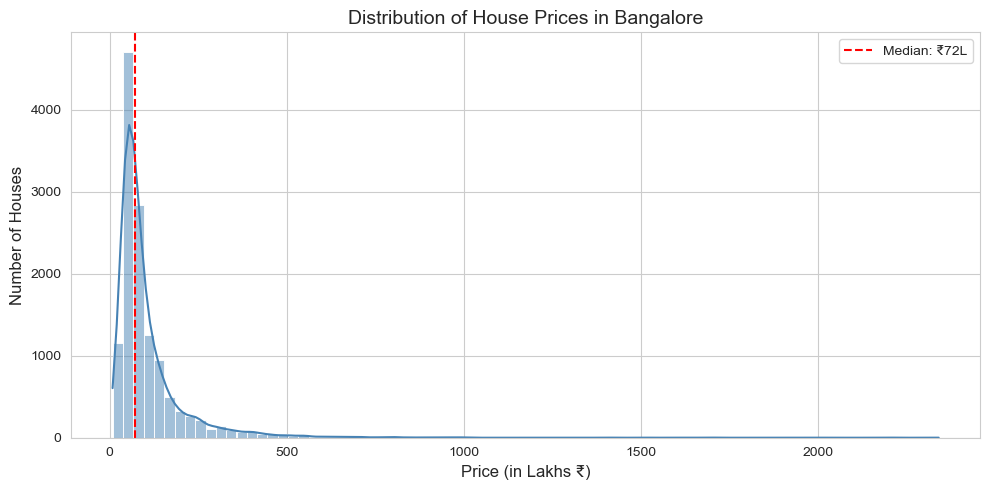

In [36]:
# Price distribution

plt.figure(figsize=(10, 5))

sns.histplot(df['price'], bins=80, color='steelblue', kde=True)

# kde=True adds a smooth curve on top of the bars

plt.title('Distribution of House Prices in Bangalore', fontsize=14)
plt.xlabel('Price (in Lakhs ₹)', fontsize=12)
plt.ylabel('Number of Houses', fontsize=12)

# Adding a vertical line showing the median price
median_price = df['price'].median()
plt.axvline(median_price, color='red', linestyle='--', linewidth=1.5,
            label=f'Median: ₹{median_price:.0f}L')

plt.legend()
plt.tight_layout()
plt.savefig('C:/Users/Asus/Desktop/Vineet Data/Project/House Price Prediction/price_distribution.png', dpi=150)
plt.show()

C:\Users\Asus\AppData\Local\Temp\ipykernel_20684\1309609354.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  bars = sns.barplot(x='bhk', y='price', data=bhk_avg, palette='Blues_d')


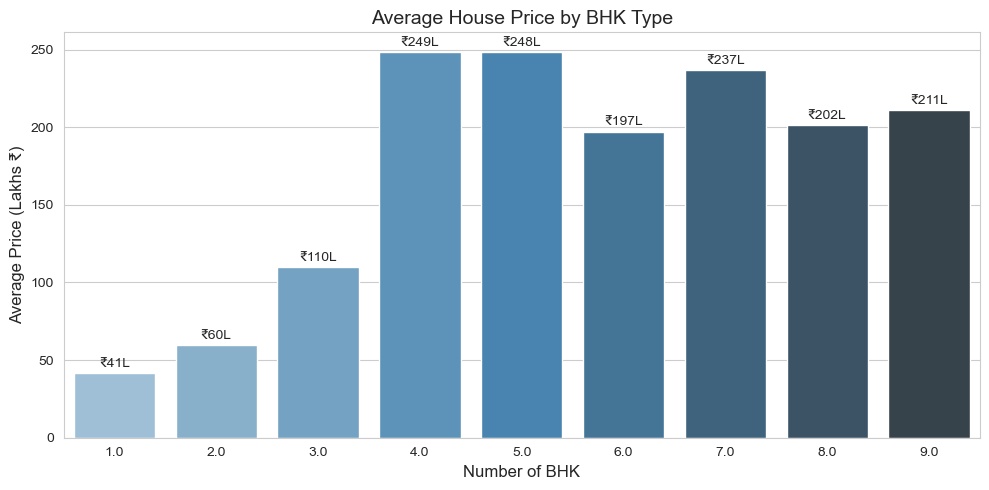

In [37]:
# Average proce by bhk

plt.figure(figsize=(10, 5))

# Calculate average price per BHK
bhk_avg = (df.groupby('bhk')['price']
             .mean()
             .reset_index()
             .sort_values('bhk'))

# Only show BHK values with enough listings (at least 20)
bhk_counts = df['bhk'].value_counts()
valid_bhk   = bhk_counts[bhk_counts >= 20].index
bhk_avg     = bhk_avg[bhk_avg['bhk'].isin(valid_bhk)]

bars = sns.barplot(x='bhk', y='price', data=bhk_avg, palette='Blues_d')

# Add price labels on top of each bar
for bar, val in zip(bars.patches, bhk_avg['price']):
    bars.text(bar.get_x() + bar.get_width() / 2,
              bar.get_height() + 2,
              f'₹{val:.0f}L',
              ha='center', va='bottom', fontsize=10)

plt.title('Average House Price by BHK Type', fontsize=14)
plt.xlabel('Number of BHK', fontsize=12)
plt.ylabel('Average Price (Lakhs ₹)', fontsize=12)
plt.tight_layout()
plt.savefig('C:/Users/Asus/Desktop/Vineet Data/Project/House Price Prediction/bhk_vs_price.png', dpi=150)
plt.show()

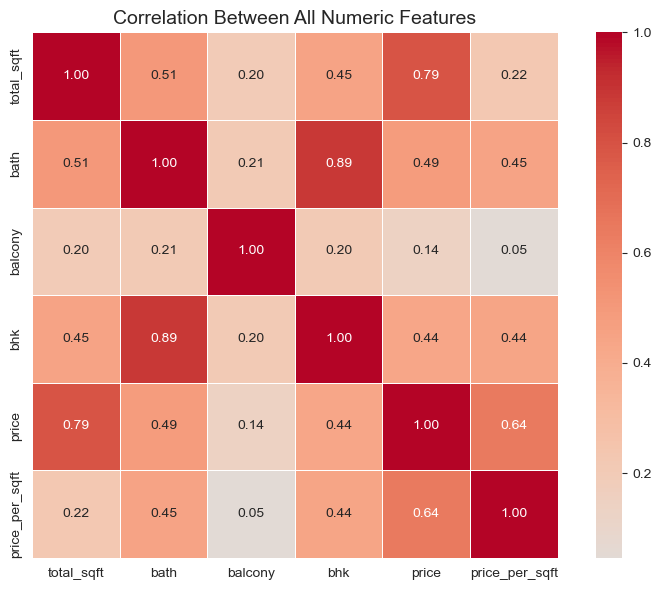

In [38]:
# Correlation Heatmap

plt.figure(figsize=(8, 6))

# Select only numeric columns for correlation
numeric_cols = ['total_sqft', 'bath', 'balcony', 'bhk', 'price', 'price_per_sqft']

# Calculate correlation — values range from -1 (opposite) to +1 (same direction)
corr_matrix = df[numeric_cols].corr()

sns.heatmap(
    corr_matrix,
    annot=True,       # show numbers inside each cell
    fmt='.2f',        # 2 decimal places
    cmap='coolwarm',  # red = positive, blue = negative
    center=0,
    linewidths=0.5,
    square=True
)

plt.title('Correlation Between All Numeric Features', fontsize=14)
plt.tight_layout()
plt.savefig('C:/Users/Asus/Desktop/Vineet Data/Project/House Price Prediction/correlation_heatmap.png', dpi=150)
plt.show()

C:\Users\Asus\AppData\Local\Temp\ipykernel_20684\2275949989.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='avg_price', y='location', data=top10, palette='Reds_r')


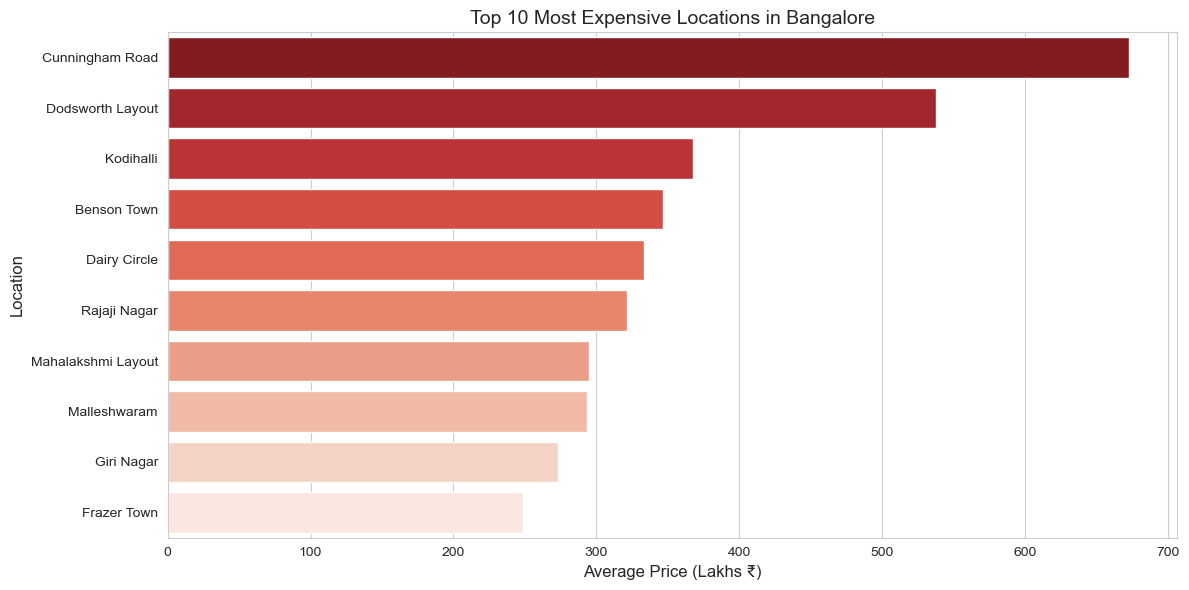


Top 10 locations:
          location  avg_price  total_listings
   Cunningham Road 673.100000              10
  Dodsworth Layout 538.200000              10
         Kodihalli 367.733333              15
       Benson Town 346.743333              15
      Dairy Circle 333.600000              10
      Rajaji Nagar 321.584078             103
Mahalakshmi Layout 294.846154              13
      Malleshwaram 293.666038              53
        Giri Nagar 273.142857              14
       Frazer Town 248.641429              35


In [39]:
#  Top 10 Most Expensive Locations

plt.figure(figsize=(12, 6))

# Get average price per location, keep only those with 10+ listings
location_stats = (df.groupby('location')
                    .agg(avg_price=('price', 'mean'),
                         total_listings=('price', 'count'))
                    .reset_index())

# Filter locations with at least 10 listings
location_stats = location_stats[location_stats['total_listings'] >= 10]

# Top 10 most expensive
top10 = location_stats.sort_values('avg_price', ascending=False).head(10)

sns.barplot(x='avg_price', y='location', data=top10, palette='Reds_r')

plt.title('Top 10 Most Expensive Locations in Bangalore', fontsize=14)
plt.xlabel('Average Price (Lakhs ₹)', fontsize=12)
plt.ylabel('Location', fontsize=12)
plt.tight_layout()
plt.savefig('C:/Users/Asus/Desktop/Vineet Data/Project/House Price Prediction/top_locations.png', dpi=150)
plt.show()

print("\nTop 10 locations:")
print(top10[['location', 'avg_price', 'total_listings']].to_string(index=False))

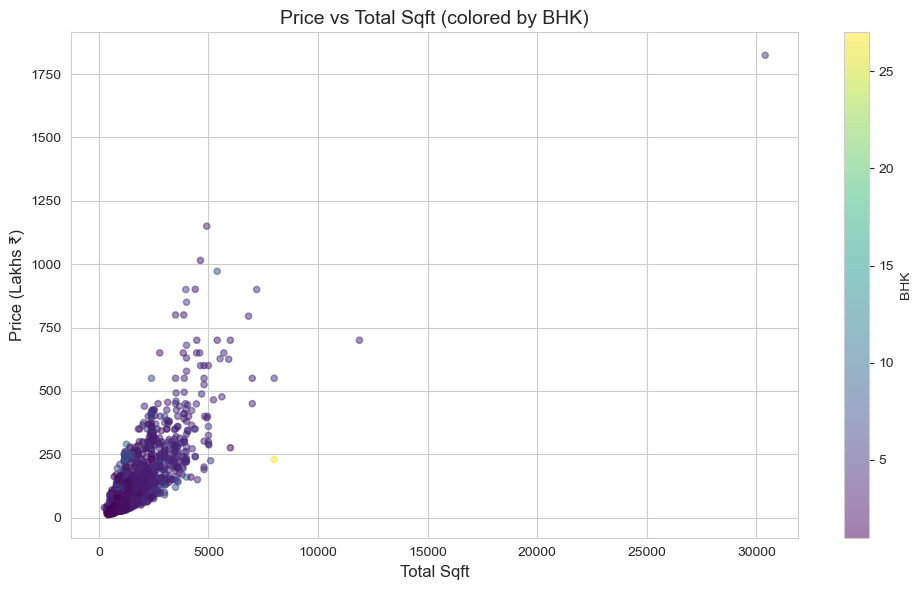

In [40]:
# Price vs Total Sqft (Scatter Plot)

plt.figure(figsize=(10, 6))

# Use a sample of 3000 points so the chart is not too crowded
sample_df = df.sample(3000, random_state=42)

# Color each point by BHK type
scatter = plt.scatter(
    sample_df['total_sqft'],
    sample_df['price'],
    c=sample_df['bhk'],        # color = BHK number
    cmap='viridis',
    alpha=0.5,                  # semi-transparent so overlapping points show
    s=20                        # dot size
)

plt.colorbar(scatter, label='BHK')
plt.title('Price vs Total Sqft (colored by BHK)', fontsize=14)
plt.xlabel('Total Sqft', fontsize=12)
plt.ylabel('Price (Lakhs ₹)', fontsize=12)
plt.tight_layout()
plt.savefig('C:/Users/Asus/Desktop/Vineet Data/Project/House Price Prediction/price_vs_sqft.png', dpi=150)
plt.show()

C:\Users\Asus\AppData\Local\Temp\ipykernel_20684\1587732494.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


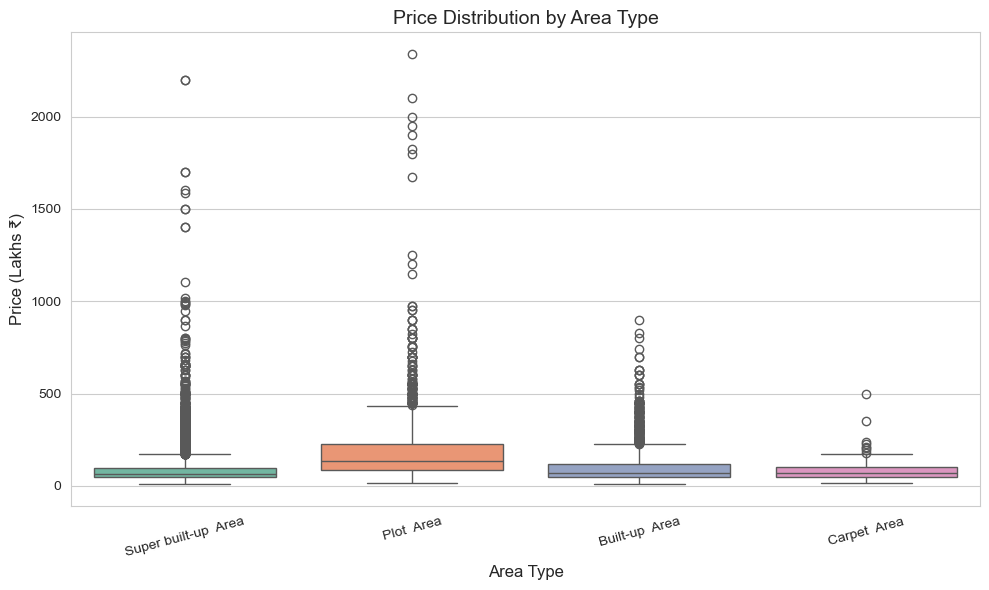

In [41]:
# Price Distribution by Area Type (Box Plot)

plt.figure(figsize=(10, 6))

sns.boxplot(
    x='area_type',
    y='price',
    data=df,
    palette='Set2'
)

plt.title('Price Distribution by Area Type', fontsize=14)
plt.xlabel('Area Type', fontsize=12)
plt.ylabel('Price (Lakhs ₹)', fontsize=12)

# Rotate x labels so they don't overlap
plt.xticks(rotation=15)
plt.tight_layout()
plt.savefig('C:/Users/Asus/Desktop/Vineet Data/Project/House Price Prediction/area_type_boxplot.png', dpi=150)
plt.show()

## Feature Engineering & ML Pipeline

In [42]:
import pandas as pd
import numpy as np
from sklearn.model_selection  import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
import joblib

In [43]:
df = pd.read_sql("SELECT * FROM houses_clean", con=engine)

In [44]:
df.head(10)

,area_type,availability,location,total_sqft,bath,balcony,price,bhk,price_per_sqft
0,Super built-up Area,19-Dec,Electronic City Phase II,1056.0,2.0,1.0,39.07,2.0,3699.810606
1,Plot Area,Ready To Move,Chikka Tirupathi,2600.0,5.0,3.0,120.00,4.0,4615.384615
2,Built-up Area,Ready To Move,Uttarahalli,1440.0,2.0,3.0,62.00,3.0,4305.555556
3,Super built-up Area,Ready To Move,Lingadheeranahalli,1521.0,3.0,1.0,95.00,3.0,6245.890861
4,Super built-up Area,Ready To Move,Kothanur,1200.0,2.0,1.0,51.00,2.0,4250.000000
5,Super built-up Area,Ready To Move,Whitefield,1170.0,2.0,1.0,38.00,2.0,3247.863248
6,Super built-up Area,18-May,Old Airport Road,2732.0,4.0,2.0,204.00,4.0,7467.057101
7,Super built-up Area,Ready To Move,Rajaji Nagar,3300.0,4.0,2.0,600.00,4.0,18181.818182
8,Super built-up Area,Ready To Move,Marathahalli,1310.0,3.0,1.0,63.25,3.0,4828.244275
9,Super built-up Area,18-Feb,Whitefield,1800.0,2.0,2.0,70.00,3.0,3888.888889


In [45]:
df.shape

(12993, 9)

In [46]:
df.columns.tolist()

['area_type',
 'availability',
 'location',
 'total_sqft',
 'bath',
 'balcony',
 'price',
 'bhk',
 'price_per_sqft']

In [47]:
# Numeric columns
numeric_features = ['total_sqft', 'bath', 'balcony', 'bhk']

# Categorical columns
categorical_features = ['area_type', 'location']

# All input features combined
all_features = numeric_features + categorical_features

# Target column — what we want to predict
target = 'price'

print("Numeric features:", numeric_features)
print("Categorical features:", categorical_features)
print("Target:", target)

Numeric features: ['total_sqft', 'bath', 'balcony', 'bhk']
Categorical features: ['area_type', 'location']
Target: price


In [48]:
X = df[all_features]   # input
y = df[target]         # output

print("X shape (features):", X.shape)
print("y shape (target)  :", y.shape)

print("First 3 rows of X:")
print(X.head(3))

print("First 3 values of y:")
print(y.head(3))

X shape (features): (12993, 6)
y shape (target)  : (12993,)
First 3 rows of X:
   total_sqft  bath  balcony  bhk             area_type  \
0      1056.0   2.0      1.0  2.0  Super built-up  Area   
1      2600.0   5.0      3.0  4.0            Plot  Area   
2      1440.0   2.0      3.0  3.0        Built-up  Area   

                   location  
0  Electronic City Phase II  
1          Chikka Tirupathi  
2               Uttarahalli  
First 3 values of y:
0     39.07
1    120.00
2     62.00
Name: price, dtype: float64


In [49]:
#  Spliting data into Training and Testing sets
# 80% of data → training
# 20% of data → testing
# random_state=42 → to get the same split every time

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42
)

print("Training set  :", X_train.shape, "← model learns from this")
print("Testing set   :", X_test.shape,  "← model is evaluated on this")

print(f"Training rows  : {len(X_train)} ({len(X_train)/len(X)*100:.1f}%)")
print(f"Testing rows   : {len(X_test)}  ({len(X_test)/len(X)*100:.1f}%)")

Training set  : (10394, 6) ← model learns from this
Testing set   : (2599, 6) ← model is evaluated on this
Training rows  : 10394 (80.0%)
Testing rows   : 2599  (20.0%)


In [50]:
# Building the pipelne
#StandardScaler to convert numbers into scaled numbers
#onehotencoding to convert text into numbers

numeric_pipeline = Pipeline(steps=[
    ('scaler', StandardScaler())
])
categorical_pipeline = Pipeline(steps=[
    ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])
# Preview unique values in categorical columns
print(f"Unique area_type values  : {df['area_type'].nunique()}")
print(f"Unique location values   : {df['location'].nunique()}")
print()
print("Sample area_type values:", df['area_type'].unique())

Unique area_type values  : 4
Unique location values   : 1274

Sample area_type values: ['Super built-up  Area' 'Plot  Area' 'Built-up  Area' 'Carpet  Area']


In [51]:
# Building the preprocessor
preprocessor = ColumnTransformer(transformers=[
    ('num', numeric_pipeline,    numeric_features),
    ('cat', categorical_pipeline, categorical_features)
],
remainder='drop')

print(f"Numeric: {numeric_features} → StandardScaler")
print(f"Categorical: {categorical_features} → OneHotEncoder")

Numeric: ['total_sqft', 'bath', 'balcony', 'bhk'] → StandardScaler
Categorical: ['area_type', 'location'] → OneHotEncoder


In [52]:
# Fitting the data on train set and then transforming the test set

X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed  = preprocessor.transform(X_test)

print(f"X_train shape before processing : {X_train.shape}")
print(f"X_train shape after  processing : {X_train_processed.shape}")
print()
print(f"X_test shape before processing  : {X_test.shape}")
print(f"X_test shape after  processing  : {X_test_processed.shape}")

X_train shape before processing : (10394, 6)
X_train shape after  processing : (10394, 1176)

X_test shape before processing  : (2599, 6)
X_test shape after  processing  : (2599, 1176)


In [53]:
# Checking if scaling worked

# Converting processed array to DataFrame to inspect it
processed_df = pd.DataFrame(
    X_train_processed[:5, :4],   # first 5 rows, first 4 columns (numeric ones)
    columns=numeric_features
)

print("Sample of SCALED numeric values (first 5 rows):")
print(processed_df.round(4))
print()
print("Notice: values are now small numbers centered around 0")
print("Original total_sqft was 1000-8000, now it is around -1 to +3")

Sample of SCALED numeric values (first 5 rows):
   total_sqft    bath  balcony     bhk
0     -0.5746  1.0741   1.7408  0.1838
1     -0.3930 -0.5360   0.4954 -0.6528
2      0.1368  0.2691   0.4954  0.1838
3     -0.6982 -0.5360   1.7408 -0.6528
4     -0.2898 -0.5360  -0.7499 -0.6528

Notice: values are now small numbers centered around 0
Original total_sqft was 1000-8000, now it is around -1 to +3


In [54]:
# Saving the preprocessor

joblib.dump(preprocessor, 'preprocessor.pkl')
np.save('C:/Users/Asus/Desktop/Vineet Data/Project/House Price Prediction/X_train_processed.npy', X_train_processed)
np.save('C:/Users/Asus/Desktop/Vineet Data/Project/House Price Prediction/X_test_processed.npy', X_test_processed)
np.save('C:/Users/Asus/Desktop/Vineet Data/Project/House Price Prediction/y_train.npy', y_train.values)
np.save('C:/Users/Asus/Desktop/Vineet Data/Project/House Price Prediction/y_test.npy', y_test.values)

In [55]:
# Saving the data in mysql

X_train_save = X_train.copy()
X_train_save['price'] = y_train.values
X_train_save['split'] = 'train'

X_test_save         = X_test.copy()
X_test_save['price'] = y_test.values
X_test_save['split'] = 'test'

import pandas as pd
split_df = pd.concat([X_train_save, X_test_save])
split_df.to_sql('houses_split', con=engine, if_exists='replace', index=False)

print("✅ Train/test split saved to MySQL table: houses_split")
print(f"   Train rows : {len(X_train_save)}")
print(f"   Test rows  : {len(X_test_save)}")

✅ Train/test split saved to MySQL table: houses_split
   Train rows : 10394
   Test rows  : 2599


## Machine Learning Models

In [56]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sqlalchemy import create_engine
import joblib

# Machine learning models
from sklearn.linear_model  import LinearRegression
from sklearn.ensemble      import RandomForestRegressor

# Evaluation metrics
from sklearn.metrics import (mean_absolute_error,
                              mean_squared_error,
                              r2_score)

sns.set_style('whitegrid')

In [57]:
X_train = np.load('C:/Users/Asus/Desktop/Vineet Data/Project/House Price Prediction/X_train_processed.npy')
X_test  = np.load('C:/Users/Asus/Desktop/Vineet Data/Project/House Price Prediction/X_test_processed.npy')
y_train = np.load('C:/Users/Asus/Desktop/Vineet Data/Project/House Price Prediction/y_train.npy')
y_test  = np.load('C:/Users/Asus/Desktop/Vineet Data/Project/House Price Prediction/y_test.npy')

print("✅ Data loaded from saved .npy files!")
print()
print(f"X_train shape : {X_train.shape}")
print(f"X_test shape  : {X_test.shape}")
print(f"y_train shape : {y_train.shape}")
print(f"y_test shape  : {y_test.shape}")
print()
print(f"Training price range  : ₹{y_train.min():.0f}L  to  ₹{y_train.max():.0f}L")
print(f"Testing price range   : ₹{y_test.min():.0f}L  to  ₹{y_test.max():.0f}L")

✅ Data loaded from saved .npy files!

X_train shape : (10394, 1176)
X_test shape  : (2599, 1176)
y_train shape : (10394,)
y_test shape  : (2599,)

Training price range  : ₹8L  to  ₹2340L
Testing price range   : ₹12L  to  ₹1824L


In [58]:
# Creating helper function to evaluate any model

def evaluate_model(model_name, y_actual, y_predicted):
    """
    Prints MAE, RMSE and R² for any model.
    
    MAE  = Mean Absolute Error    → average prediction error in Lakhs
    RMSE = Root Mean Squared Error → penalizes large errors more than MAE
    R²   = R-squared              → how much price variation model explains
           0.0 = model learned nothing
           1.0 = model is perfect
           0.85 = model explains 85% of price variation
    """
    mae  = mean_absolute_error(y_actual, y_predicted)
    rmse = np.sqrt(mean_squared_error(y_actual, y_predicted))
    r2   = r2_score(y_actual, y_predicted)

    print(f"=== {model_name} ===")
    print(f"  MAE  (avg error)          : ₹{mae:.2f} Lakhs")
    print(f"  RMSE (penalizes big errors): ₹{rmse:.2f} Lakhs")
    print(f"  R²   (explains variation)  : {r2:.4f}  ({r2*100:.1f}%)")
    print()

    return {'model': model_name, 'MAE': round(mae, 2),
            'RMSE': round(rmse, 2), 'R2': round(r2, 4)}

In [59]:
# Linear regression

lr_model = LinearRegression()

# .fit() = the model LEARNS from training data
# It adjusts all the weights to minimize prediction error
lr_model.fit(X_train, y_train)

print("✅ Linear Regression trained!")
print(f"Number of weights learned: {len(lr_model.coef_)}")
print(f"Bias (intercept) value : {lr_model.intercept_:.4f}")

✅ Linear Regression trained!
Number of weights learned: 1176
Bias (intercept) value : 120.5810


In [60]:
# .predict() = use learned weights to predict prices on test data
y_pred_lr = lr_model.predict(X_test)

# Evaluate using our helper function
lr_results = evaluate_model("Linear Regression", y_test, y_pred_lr)

# Show a few actual vs predicted examples
print("Sample predictions (first 8 test houses):")
print(f"{'Actual Price':>15}  {'Predicted Price':>16}  {'Difference':>12}")
print("-" * 48)
for actual, predicted in zip(y_test[:8], y_pred_lr[:8]):
    diff = predicted - actual
    print(f"₹{actual:>12.2f}L   ₹{predicted:>13.2f}L   {diff:>+10.2f}L")

=== Linear Regression ===
  MAE  (avg error)          : ₹30.48 Lakhs
  RMSE (penalizes big errors): ₹56.63 Lakhs
  R²   (explains variation)  : 0.7204  (72.0%)

Sample predictions (first 8 test houses):
   Actual Price   Predicted Price    Difference
------------------------------------------------
₹       75.00L   ₹        64.58L       -10.42L
₹      334.00L   ₹       326.55L        -7.45L
₹      160.00L   ₹       114.36L       -45.64L
₹       58.00L   ₹        55.51L        -2.49L
₹      110.00L   ₹       128.21L       +18.21L
₹       74.31L   ₹        51.72L       -22.59L
₹       42.47L   ₹        47.66L        +5.19L
₹       82.00L   ₹        23.73L       -58.27L


In [61]:
# training random forest

rf_model = RandomForestRegressor(
    n_estimators=100,   # number of trees
    max_depth=15,       # max depth of each tree (prevents overfitting)
    min_samples_leaf=5, # each leaf must have at least 5 samples
    random_state=42,    # reproducibility
    n_jobs=-1           # use all CPU cores to train faster
)

rf_model.fit(X_train, y_train)

print("Random Forest trained!")
print(f" Number of trees: {rf_model.n_estimators}")
print(f"Number of features: {rf_model.n_features_in_}")

Random Forest trained!
 Number of trees: 100
Number of features: 1176


In [62]:
y_pred_rf = rf_model.predict(X_test)

rf_results = evaluate_model("Random Forest", y_test, y_pred_rf)

# Show same 8 examples for direct comparison
print("Sample predictions (same 8 test houses as Linear Regression):")
print(f"{'Actual Price':>15}  {'Predicted Price':>16}  {'Difference':>12}")
print("-" * 48)
for actual, predicted in zip(y_test[:8], y_pred_rf[:8]):
    diff = predicted - actual
    print(f"₹{actual:>12.2f}L   ₹{predicted:>13.2f}L   {diff:>+10.2f}L")

=== Random Forest ===
  MAE  (avg error)          : ₹28.45 Lakhs
  RMSE (penalizes big errors): ₹58.98 Lakhs
  R²   (explains variation)  : 0.6966  (69.7%)

Sample predictions (same 8 test houses as Linear Regression):
   Actual Price   Predicted Price    Difference
------------------------------------------------
₹       75.00L   ₹        68.66L        -6.34L
₹      334.00L   ₹       341.00L        +7.00L
₹      160.00L   ₹       139.82L       -20.18L
₹       58.00L   ₹        72.97L       +14.97L
₹      110.00L   ₹       111.91L        +1.91L
₹       74.31L   ₹        67.09L        -7.22L
₹       42.47L   ₹        47.67L        +5.20L
₹       82.00L   ₹        66.59L       -15.41L


In [63]:
# Combining all results
all_results = pd.DataFrame([lr_results, rf_results])

print("=" * 55)
print(" FINAL MODEL COMPARISON TABLE")
print("=" * 55)
print(all_results.to_string(index=False))
print("=" * 55)
print()
print("Lower MAE  and RMSE = better (smaller error)")
print("Higher R²  = better (explains more variation)")
print()


best_r2 = all_results.loc[all_results['R2'].idxmax(), 'model']
print(f"🏆 Best model so far: {best_r2}")

 FINAL MODEL COMPARISON TABLE
            model   MAE  RMSE     R2
Linear Regression 30.48 56.63 0.7204
    Random Forest 28.45 58.98 0.6966

Lower MAE  and RMSE = better (smaller error)
Higher R²  = better (explains more variation)

🏆 Best model so far: Linear Regression


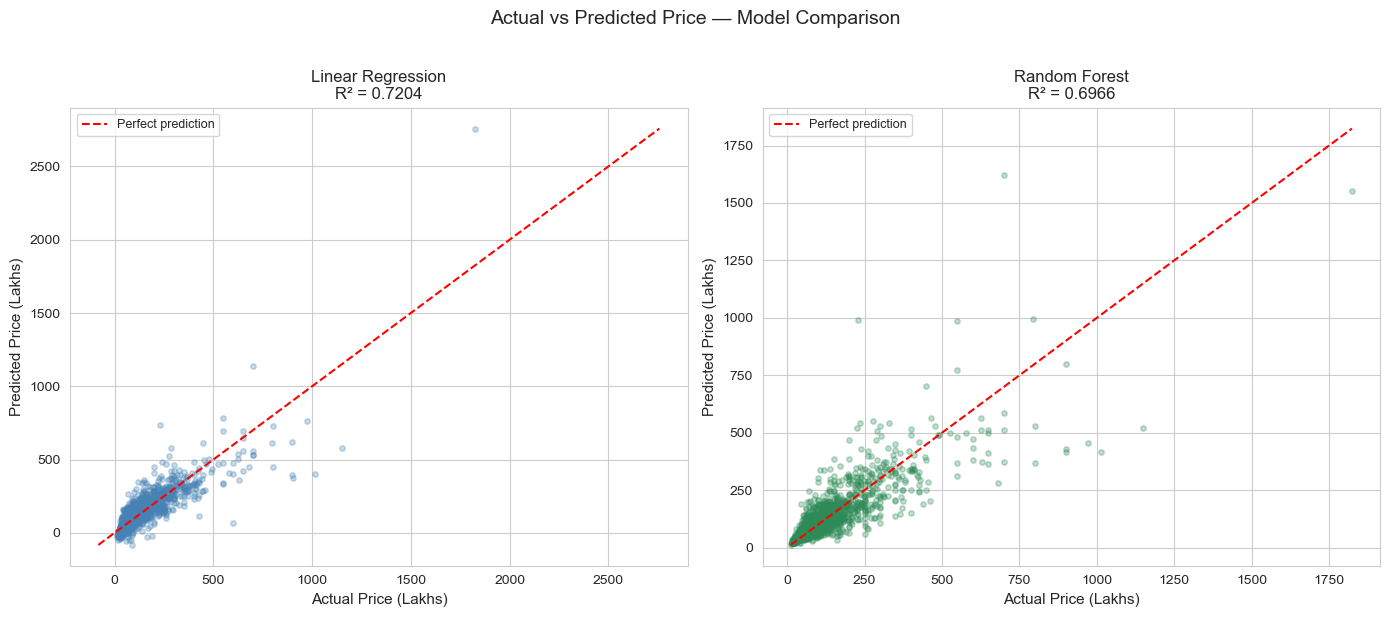

In [64]:
# Actual vs Predicted model

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

models_data = [
    ("Linear Regression", y_pred_lr, "steelblue"),
    ("Random Forest",     y_pred_rf, "seagreen")
]

for ax, (name, y_pred, color) in zip(axes, models_data):
    ax.scatter(y_test, y_pred, alpha=0.3, color=color, s=15)

    # Perfect prediction line (if model was 100% accurate,
    # all dots would sit exactly on this line)
    min_val = min(y_test.min(), y_pred.min())
    max_val = max(y_test.max(), y_pred.max())
    ax.plot([min_val, max_val], [min_val, max_val],
            'r--', linewidth=1.5, label='Perfect prediction')

    ax.set_title(f'{name}\nR² = {r2_score(y_test, y_pred):.4f}', fontsize=12)
    ax.set_xlabel('Actual Price (Lakhs)', fontsize=11)
    ax.set_ylabel('Predicted Price (Lakhs)', fontsize=11)
    ax.legend(fontsize=9)

plt.suptitle('Actual vs Predicted Price — Model Comparison', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('C:/Users/Asus/Desktop/Vineet Data/Project/House Price Prediction/actual_vs_predicted.png', dpi=150)
plt.show()

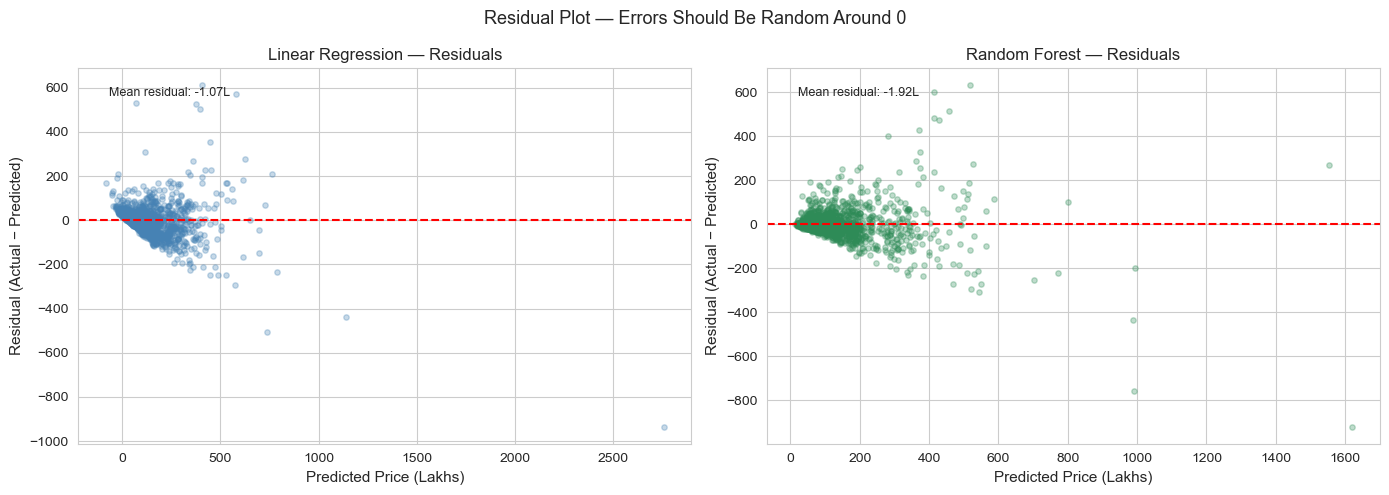

In [65]:
# Visualize: Residuals
# Residual = Actual Price - Predicted Price

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, (name, y_pred, color) in zip(axes, models_data):
    residuals = y_test - y_pred

    ax.scatter(y_pred, residuals, alpha=0.3, color=color, s=15)
    ax.axhline(0, color='red', linestyle='--', linewidth=1.5)

    ax.set_title(f'{name} — Residuals', fontsize=12)
    ax.set_xlabel('Predicted Price (Lakhs)', fontsize=11)
    ax.set_ylabel('Residual (Actual − Predicted)', fontsize=11)

    # Add mean residual annotation
    mean_res = residuals.mean()
    ax.text(0.05, 0.95, f'Mean residual: {mean_res:.2f}L',
            transform=ax.transAxes, fontsize=9,
            verticalalignment='top')

plt.suptitle('Residual Plot — Errors Should Be Random Around 0', fontsize=13)
plt.tight_layout()
plt.savefig('C:/Users/Asus/Desktop/Vineet Data/Project/House Price Prediction/residuals.png', dpi=150)
plt.show()

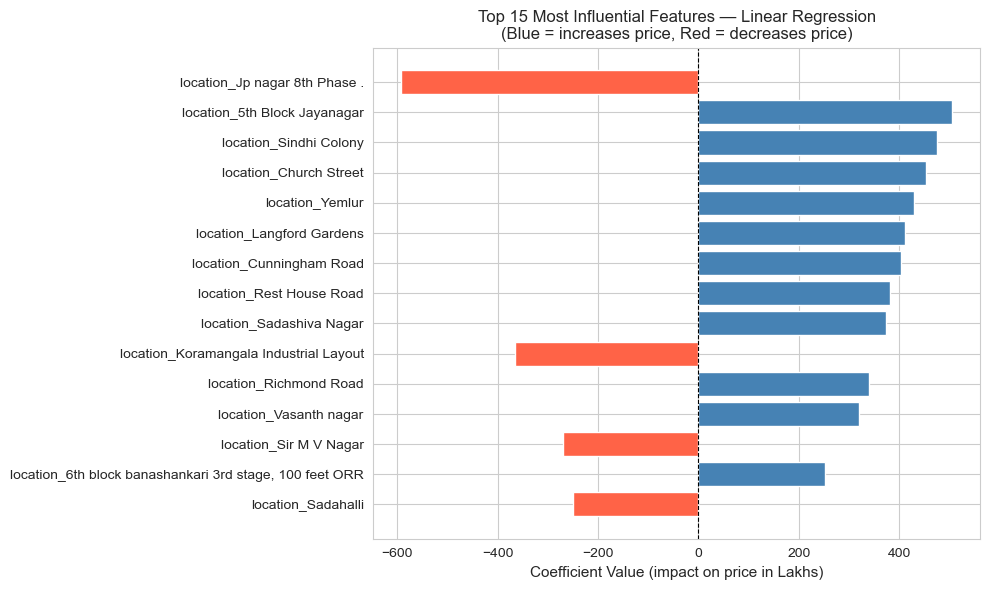


Top 10 features by absolute influence:
Rank   Feature                                   Coefficient    Direction
------------------------------------------------------------------------
1      location_Jp nagar 8th Phase .                 -592.12  decreases price
2      location_5th Block Jayanagar                  +506.10  increases price
3      location_Sindhi Colony                        +475.25  increases price
4      location_Church Street                        +452.53  increases price
5      location_Yemlur                               +428.87  increases price
6      location_Langford Gardens                     +411.66  increases price
7      location_Cunningham Road                      +404.25  increases price
8      location_Rest House Road                      +381.22  increases price
9      location_Sadashiva Nagar                      +372.87  increases price
10     location_Koramangala Industrial Layout        -365.09  decreases price


In [66]:
# Feature importance

preprocessor = joblib.load('preprocessor.pkl')

numeric_features     = ['total_sqft', 'bath', 'balcony', 'bhk']
categorical_features = ['area_type', 'location']

# Get one-hot encoded column names
ohe_feature_names = (preprocessor
                     .named_transformers_['cat']
                     .named_steps['encoder']
                     .get_feature_names_out(categorical_features))

all_feature_names = np.array(numeric_features + list(ohe_feature_names))

# Linear Regression coefficients = how much each feature influences price
# Positive coefficient → feature increases price
# Negative coefficient → feature decreases price
# Larger absolute value → stronger influence

coefficients     = lr_model.coef_
abs_coefficients = np.abs(coefficients)

# Top 15 most influential features
top_n   = 15
top_idx = np.argsort(abs_coefficients)[::-1][:top_n]

plt.figure(figsize=(10, 6))

colors = ['steelblue' if coefficients[i] > 0 else 'tomato'
          for i in top_idx]

plt.barh(
    all_feature_names[top_idx][::-1],
    coefficients[top_idx][::-1],
    color=colors[::-1]
)

plt.axvline(0, color='black', linewidth=0.8, linestyle='--')
plt.title('Top 15 Most Influential Features — Linear Regression\n(Blue = increases price, Red = decreases price)',
          fontsize=12)
plt.xlabel('Coefficient Value (impact on price in Lakhs)', fontsize=11)
plt.tight_layout()
plt.savefig('C:/Users/Asus/Desktop/Vineet Data/Project/House Price Prediction/lr_coefficients.png', dpi=150)
plt.show()

print("\nTop 10 features by absolute influence:")
print(f"{'Rank':<6} {'Feature':<40} {'Coefficient':>12} {'Direction':>12}")
print("-" * 72)
for i, idx in enumerate(top_idx[:10]):
    direction = "increases price" if coefficients[idx] > 0 else "decreases price"
    print(f"{i+1:<6} {all_feature_names[idx]:<40} {coefficients[idx]:>+12.2f} {direction:>16}")

In [67]:
# Saving the model

joblib.dump(lr_model, 'lr_model.pkl')
joblib.dump(lr_model, 'best_model.pkl')   # also save a copy called best_model

print("✅ Linear Regression saved as lr_model.pkl")
print("✅ Also saved as best_model.pkl")
print()

# Confirm by reloading and checking it works
test_load = joblib.load('best_model.pkl')
test_pred = test_load.predict(X_test[:3])

print("Verification — predictions from reloaded model:")
print(f"Predicted: {[round(p, 2) for p in test_pred]}")
print(f"Actual: {[round(a, 2) for a in y_test[:3]]}")
print()
print("If predicted and actual are close → model saved correctly ✅")

✅ Linear Regression saved as lr_model.pkl
✅ Also saved as best_model.pkl

Verification — predictions from reloaded model:
Predicted: [np.float64(64.58), np.float64(326.55), np.float64(114.36)]
Actual: [np.float64(75.0), np.float64(334.0), np.float64(160.0)]

If predicted and actual are close → model saved correctly ✅


In [68]:
# saving toi mysql
results_df = pd.DataFrame([lr_results, rf_results])
results_df['trained_on_rows'] = len(X_train)
results_df['tested_on_rows'] = len(X_test)
results_df['day'] = 5
results_df['is_winner'] = results_df['R2'] == results_df['R2'].max()

# Save to MySQL
results_df.to_sql('model_results', con=engine,
                  if_exists='replace', index=False)

print("✅ Results saved to MySQL table: model_results")

print(results_df[['model', 'MAE', 'RMSE', 'R2', 'is_winner']]
      .to_string(index=False))

winner = results_df.loc[results_df['is_winner'], 'model'].values[0]
best   = results_df.loc[results_df['is_winner']]


✅ Results saved to MySQL table: model_results
            model   MAE  RMSE     R2  is_winner
Linear Regression 30.48 56.63 0.7204       True
    Random Forest 28.45 58.98 0.6966      False


## Neural Networks

In [69]:
# Importing required libraries
import joblib
import tensorflow as tf
from tensorflow import keras
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [70]:
# Loading the data
X_train = np.load('X_train_processed.npy')
X_test  = np.load('X_test_processed.npy')
y_train = np.load('y_train.npy')
y_test  = np.load('y_test.npy')

In [71]:
X_train.shape

(10394, 1176)

In [72]:
X_test.shape

(2599, 1176)

In [73]:
y_train.shape

(10394,)

In [74]:
y_test.shape

(2599,)

In [75]:
print(y_train.min())

8.0


In [76]:
print(y_train.max())

2340.0


In [77]:
## We will create below layers
### Input layer will be of 1176
### hidden layer 1 (dense 256, with activation function ReLU)
### hidden layer 2 (Dense 128, with activation function ReLU)
### hidden layer 3 (Dense 64, with activation function ReLU)
### Output layer 1 
### 1176 inputs → Dense(256) → Dense(128) → Dense(64) → 1 output (price)

In [78]:
input_shape = X_train.shape[1]  # Number of input features
print(f"Number of input features: {input_shape}")

# Building model layer by layer
model = keras.Sequential([

    # Layer 1: First hidden layer
    keras.layers.Dense(
        256,
        activation='relu',
        input_shape=(input_shape,)   
    ),
    keras.layers.BatchNormalization(),  # to stabilize training
    keras.layers.Dropout(0.3),          # dropping 30% neurons randomly

    # Layer 2: Second hidden layer
    keras.layers.Dense(128, activation='relu'),
    keras.layers.BatchNormalization(),
    keras.layers.Dropout(0.2),          # dropping 20% neurons randomly

    # Layer 3: Third hidden layer 
    keras.layers.Dense(64, activation='relu'),
    keras.layers.BatchNormalization(),
    keras.layers.Dropout(0.1),          # dropping 10% neurons randomly

    keras.layers.Dense(1)

])
model.summary()

Number of input features: 1176


C:\Users\Asus\AppData\Roaming\Python\Python313\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 256)            │       301,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 344,321 (1.31 MB)

 Trainable params: 343,425 (1.31 MB)

 Non-trainable params: 896 (3.50 KB)

In [79]:
# Compiling the model (telling model how to learn)
# We will use adam optimizer which will update weights after each batch
# mae(mean absolute error) will be loss function

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='mae',
    metrics=['mse']
)

In [80]:
# Setting training callbacks(rules the training will follow)
# Early stopping will stop training if validation loss stops improving for 20 epochs

early_stop = keras.callbacks.EarlyStopping(
    monitor='val_loss',         # watch validation loss
    patience=20,                # wait 20 epochs before stopping
    restore_best_weights=True,  # go back to the best epoch
    verbose=1                   # print message when it stops
)

# Reducing learning rate if learning stalls
reduce_lr = keras.callbacks.ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,      # new lr = old lr × 0.5
    patience=10,     # wait 10 epochs before reducing
    min_lr=0.00001,  # never go below this learning rate
    verbose=1
)

# saving model automatically whenever it improves
checkpoint = keras.callbacks.ModelCheckpoint(
    'best_nn_model.keras',   # save to this file
    monitor='val_loss',
    save_best_only=True,     # only save when improved
    verbose=1
)

In [81]:
history = model.fit(
    X_train, y_train,
    epochs=300,              # max 300 rounds (early stopping will kick in)
    batch_size=64,           # process 64 houses at a time per step
    validation_split=0.2,    # use 20% of training data for validation
    callbacks=[early_stop, reduce_lr, checkpoint],
    verbose=1                # print progress each epoch
)

print(f"Total epochs run: {len(history.history['loss'])}")
print(f"Best val_loss (MAE): ₹{min(history.history['val_loss']):.2f} Lakhs")

Epoch 1/300
130/130 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 106.2849 - mse: 25982.2048
Epoch 1: val_loss improved from None to 107.99628, saving model to best_nn_model.keras

Epoch 1: finished saving model to best_nn_model.keras
130/130 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 106.1527 - mse: 25913.7637 - val_loss: 107.9963 - val_mse: 27790.0410 - learning_rate: 0.0010
Epoch 2/300
122/130 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 102.4034 - mse: 24162.3882
Epoch 2: val_loss improved from 107.99628 to 101.56271, saving model to best_nn_model.keras

Epoch 2: finished saving model to best_nn_model.keras
130/130 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 101.2049 - mse: 24807.1426 - val_loss: 101.5627 - val_mse: 26492.8867 - learning_rate: 0.0010
Epoch 3/300
121/130 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 95.5668 - mse: 24345.8191
Epoch 3: val_loss improved from 101.56271 to 88.32469, saving model to best_nn_model.keras

Epoch 3: finished saving model to best_nn_model.keras
130/130 ━━━━━━━━

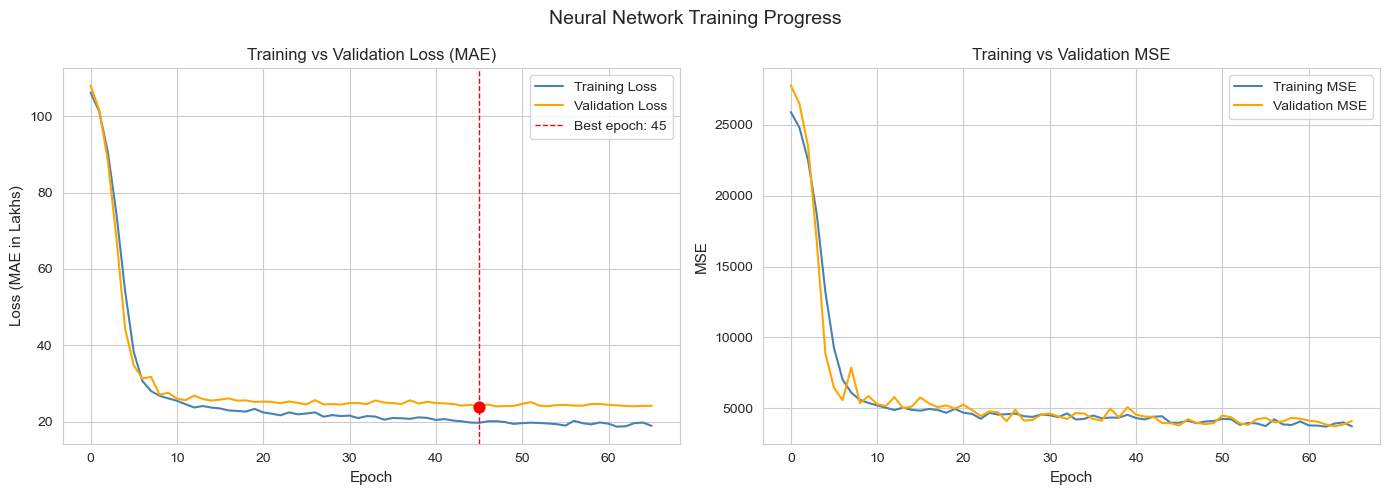

Best epoch    : 45
Best val loss : ₹24.01 Lakhs


In [82]:
# plotting the training history

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

epochs_ran = len(history.history['loss'])

# Plot 1: Loss (MAE) over epochs
axes[0].plot(history.history['loss'],
             label='Training Loss',   color='steelblue', linewidth=1.5)
axes[0].plot(history.history['val_loss'],
             label='Validation Loss', color='orange',    linewidth=1.5)

# Mark the best epoch
best_epoch = np.argmin(history.history['val_loss'])
best_val   = min(history.history['val_loss'])
axes[0].axvline(best_epoch, color='red', linestyle='--',
                linewidth=1, label=f'Best epoch: {best_epoch}')
axes[0].scatter(best_epoch, best_val, color='red', zorder=5, s=60)

axes[0].set_title('Training vs Validation Loss (MAE)', fontsize=12)
axes[0].set_xlabel('Epoch', fontsize=11)
axes[0].set_ylabel('Loss (MAE in Lakhs)', fontsize=11)
axes[0].legend()

#  Plot 2: MSE over epochs
axes[1].plot(history.history['mse'],
             label='Training MSE',   color='steelblue', linewidth=1.5)
axes[1].plot(history.history['val_mse'],
             label='Validation MSE', color='orange',    linewidth=1.5)

axes[1].set_title('Training vs Validation MSE', fontsize=12)
axes[1].set_xlabel('Epoch', fontsize=11)
axes[1].set_ylabel('MSE', fontsize=11)
axes[1].legend()

plt.suptitle('Neural Network Training Progress', fontsize=14)
plt.tight_layout()
plt.savefig('C:/Users/Asus/Desktop/Vineet Data/Project/House Price Prediction/training_history.png', dpi=150)
plt.show()

print(f"Best epoch    : {best_epoch}")
print(f"Best val loss : ₹{best_val:.2f} Lakhs")

In [83]:
# loading the best model and making prediction on test data

best_model = keras.models.load_model('best_nn_model.keras')

print("✅ Best model loaded from checkpoint!")
print()

# Making predictions on test data
y_pred_nn = best_model.predict(X_test, verbose=0).flatten()

# Calculate all metrics
mae_nn  = mean_absolute_error(y_test, y_pred_nn)
rmse_nn = np.sqrt(mean_squared_error(y_test, y_pred_nn))
r2_nn   = r2_score(y_test, y_pred_nn)

print(f"MAE(avg error): ₹{mae_nn:.2f} Lakhs")
print(f"RMSE(penalizes big errors): ₹{rmse_nn:.2f} Lakhs")
print(f"R²(explains variation): {r2_nn:.4f}  ({r2_nn*100:.1f}%)")

✅ Best model loaded from checkpoint!

MAE(avg error): ₹21.87 Lakhs
RMSE(penalizes big errors): ₹46.35 Lakhs
R²(explains variation): 0.8127  (81.3%)


In [84]:
# Comparing all 3 models

results = pd.read_sql("SELECT model, MAE, RMSE, R2 FROM model_results", con=engine)

# Add Neural Network row
nn_row = pd.DataFrame([{
    'model': 'Neural Network',
    'MAE'  : round(mae_nn, 2),
    'RMSE' : round(rmse_nn, 2),
    'R2'   : round(r2_nn, 4)
}])

all_results = pd.concat([results, nn_row], ignore_index=True)
all_results['is_winner'] = all_results['R2'] == all_results['R2'].max()


print(" FINAL 3-MODEL COMPARISON TABLE ")

print(all_results[['model', 'MAE', 'RMSE', 'R2', 'is_winner']]
      .to_string(index=False))


winner = all_results.loc[all_results['R2'].idxmax(), 'model']
print(f"Overall Winner : {winner}")

 FINAL 3-MODEL COMPARISON TABLE 
            model   MAE  RMSE     R2  is_winner
Linear Regression 30.48 56.63 0.7204      False
    Random Forest 28.45 58.98 0.6966      False
   Neural Network 21.87 46.35 0.8127       True
Overall Winner : Neural Network


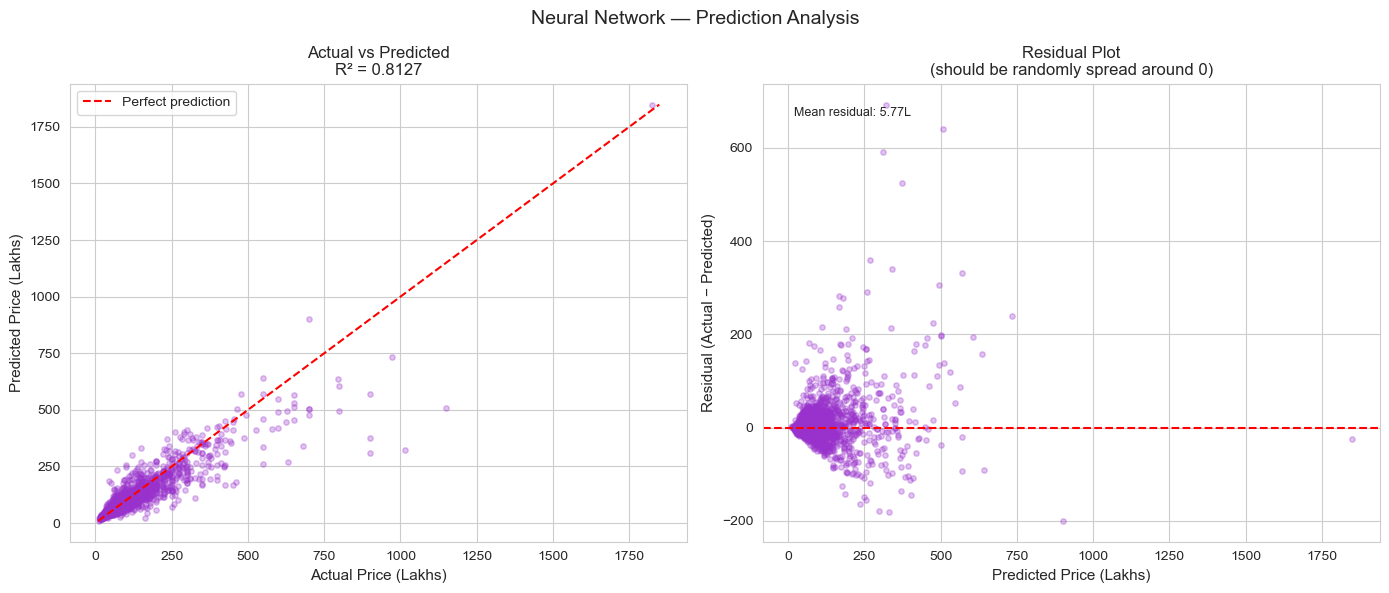

In [85]:
# Visualize: Actual vs Predicted 

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Plot 1: Scatter — Actual vs Predicted
axes[0].scatter(y_test, y_pred_nn, alpha=0.3, color='darkorchid', s=15)

# Perfect prediction line
min_val = min(y_test.min(), y_pred_nn.min())
max_val = max(y_test.max(), y_pred_nn.max())
axes[0].plot([min_val, max_val], [min_val, max_val],
             'r--', linewidth=1.5, label='Perfect prediction')

axes[0].set_title(f'Actual vs Predicted\nR² = {r2_nn:.4f}', fontsize=12)
axes[0].set_xlabel('Actual Price (Lakhs)', fontsize=11)
axes[0].set_ylabel('Predicted Price (Lakhs)', fontsize=11)
axes[0].legend()

# Plot 2: Residuals
residuals = y_test - y_pred_nn

axes[1].scatter(y_pred_nn, residuals, alpha=0.3, color='darkorchid', s=15)
axes[1].axhline(0, color='red', linestyle='--', linewidth=1.5)

axes[1].set_title('Residual Plot\n(should be randomly spread around 0)',
                  fontsize=12)
axes[1].set_xlabel('Predicted Price (Lakhs)', fontsize=11)
axes[1].set_ylabel('Residual (Actual − Predicted)', fontsize=11)

mean_res = residuals.mean()
axes[1].text(0.05, 0.95, f'Mean residual: {mean_res:.2f}L',
             transform=axes[1].transAxes, fontsize=9,
             verticalalignment='top')

plt.suptitle('Neural Network — Prediction Analysis', fontsize=14)
plt.tight_layout()
plt.savefig('C:/Users/Asus/Desktop/Vineet Data/Project/House Price Prediction/nn_predictions.png', dpi=150)
plt.show()

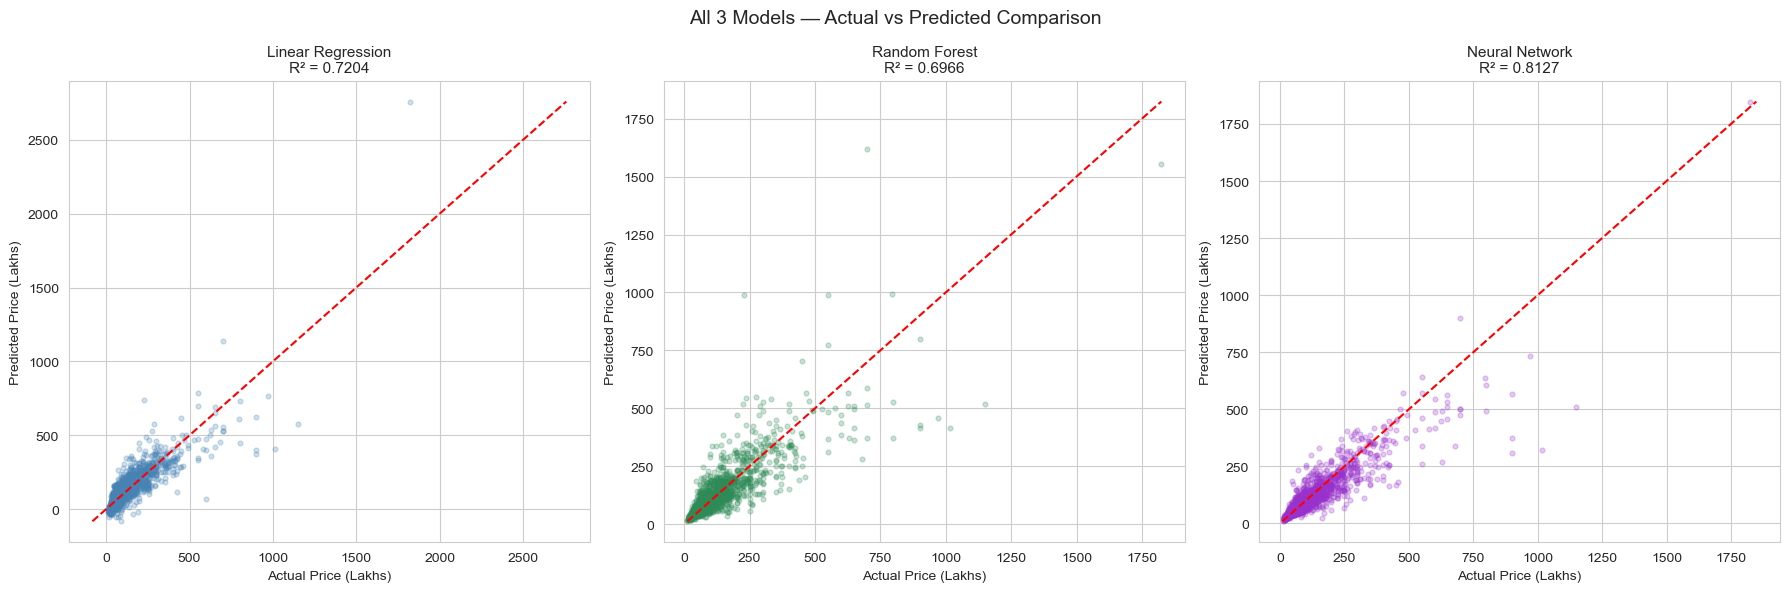

The tighter dots hug the red diagonal → the better the model


In [86]:
# Comparing all 3 models visually

joblib.dump(rf_model, 'rf_model.pkl')

lr_model = joblib.load('lr_model.pkl')
rf_model = joblib.load('rf_model.pkl')

y_pred_lr = lr_model.predict(X_test)
y_pred_rf = rf_model.predict(X_test)

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

models_info = [
    ("Linear Regression", y_pred_lr, "steelblue",  r2_score(y_test, y_pred_lr)),
    ("Random Forest",     y_pred_rf, "seagreen",   r2_score(y_test, y_pred_rf)),
    ("Neural Network",    y_pred_nn, "darkorchid", r2_nn)
]

for ax, (name, y_pred, color, r2) in zip(axes, models_info):
    ax.scatter(y_test, y_pred, alpha=0.25, color=color, s=12)

    min_val = min(y_test.min(), y_pred.min())
    max_val = max(y_test.max(), y_pred.max())
    ax.plot([min_val, max_val], [min_val, max_val],
            'r--', linewidth=1.5)

    ax.set_title(f'{name}\nR² = {r2:.4f}', fontsize=11)
    ax.set_xlabel('Actual Price (Lakhs)', fontsize=10)
    ax.set_ylabel('Predicted Price (Lakhs)', fontsize=10)

plt.suptitle('All 3 Models — Actual vs Predicted Comparison', fontsize=14)
plt.tight_layout()
plt.savefig('C:/Users/Asus/Desktop/Vineet Data/Project/House Price Prediction/all_models_comparison.png', dpi=150)
plt.show()

print("The tighter dots hug the red diagonal → the better the model")

In [87]:
# Saving the results

all_results['model_used'] = all_results['model'].apply(
    lambda x: 'Linear Regression' if x == 'Linear Regression'
              else 'Random Forest' if x == 'Random Forest'
              else 'Neural Network'
)
all_results['trained_on_rows'] = len(X_train)
all_results['tested_on_rows']  = len(X_test)

all_results.to_sql('model_results', con=engine,
                   if_exists='replace', index=False)

3

## Predict Function

In [90]:
# Loading data

X_train = np.load('X_train_processed.npy')
X_test  = np.load('X_test_processed.npy')
y_train = np.load('y_train.npy')
y_test  = np.load('y_test.npy')

# Loading all 3 models
lr_model   = joblib.load('lr_model.pkl')
rf_model   = joblib.load('rf_model.pkl')
best_model = keras.models.load_model('best_nn_model.keras')

# Loading preprocessor
preprocessor = joblib.load('preprocessor.pkl')

In [91]:
X_train.shape

(10394, 1176)

In [92]:
X_test.shape

(2599, 1176)

In [93]:
# Generating prediction from every model

y_pred_lr = lr_model.predict(X_test)
y_pred_rf = rf_model.predict(X_test)
y_pred_nn = best_model.predict(X_test, verbose=0).flatten()

print(f"First 5 actual prices: {np.round(y_test[:5],2)}")
print(f"Linear Regression preds: {np.round(y_pred_lr[:5],2)}")
print(f"Random Forest preds: {np.round(y_pred_rf[:5],2)}")
print(f"Neural Network preds: {np.round(y_pred_nn[:5],2)}")

First 5 actual prices: [ 75. 334. 160.  58. 110.]
Linear Regression preds: [ 64.58 326.55 114.36  55.51 128.21]
Random Forest preds: [ 68.66 341.   139.82  72.97 111.91]
Neural Network preds: [ 76.92 340.35 156.43  63.5   87.54]


In [95]:
# Final Evaluation

def evaluate_model(name, y_actual, y_predicted):
    mae  = mean_absolute_error(y_actual, y_predicted)
    rmse = np.sqrt(mean_squared_error(y_actual, y_predicted))
    r2   = r2_score(y_actual, y_predicted)
    return {'Model': name,
            'MAE (Lakhs)' : round(mae,  2),
            'RMSE (Lakhs)': round(rmse, 2),
            'R² Score'    : round(r2,   4),
            'Accuracy %'  : round(r2 * 100, 1)}

lr_res = evaluate_model("Linear Regression", y_test, y_pred_lr)
rf_res = evaluate_model("Random Forest",     y_test, y_pred_rf)
nn_res = evaluate_model("Neural Network",    y_test, y_pred_nn)

final_df = pd.DataFrame([lr_res, rf_res, nn_res])

print("=" * 68)
print("COMPLETE PROJECT — FINAL MODEL COMPARISON")
print("=" * 68)
print(final_df.to_string(index=False))
print("=" * 68)
print()

# Highlighting improvrment

nn_mae = nn_res['MAE (Lakhs)']
lr_mae = lr_res['MAE (Lakhs)']
nn_r2  = nn_res['R² Score']
lr_r2  = lr_res['R² Score']

print(f"Neural Network vs Linear Regression:")
print(f"MAE improved by: ₹{lr_mae - nn_mae:.2f} Lakhs less error per prediction")
print(f"R² improved by: +{nn_r2 - lr_r2:.4f} ({(nn_r2-lr_r2)*100:.1f}% better)")
print()
print(f"Winner: Neural Network")
print(f"Explains {nn_r2*100:.1f}% of all house price variation in Bangalore")

COMPLETE PROJECT — FINAL MODEL COMPARISON
            Model  MAE (Lakhs)  RMSE (Lakhs)  R² Score  Accuracy %
Linear Regression        30.48         56.63    0.7204        72.0
    Random Forest        28.45         58.98    0.6966        69.7
   Neural Network        21.87         46.35    0.8127        81.3

Neural Network vs Linear Regression:
MAE improved by: ₹8.61 Lakhs less error per prediction
R² improved by: +0.0923 (9.2% better)

Winner: Neural Network
Explains 81.3% of all house price variation in Bangalore


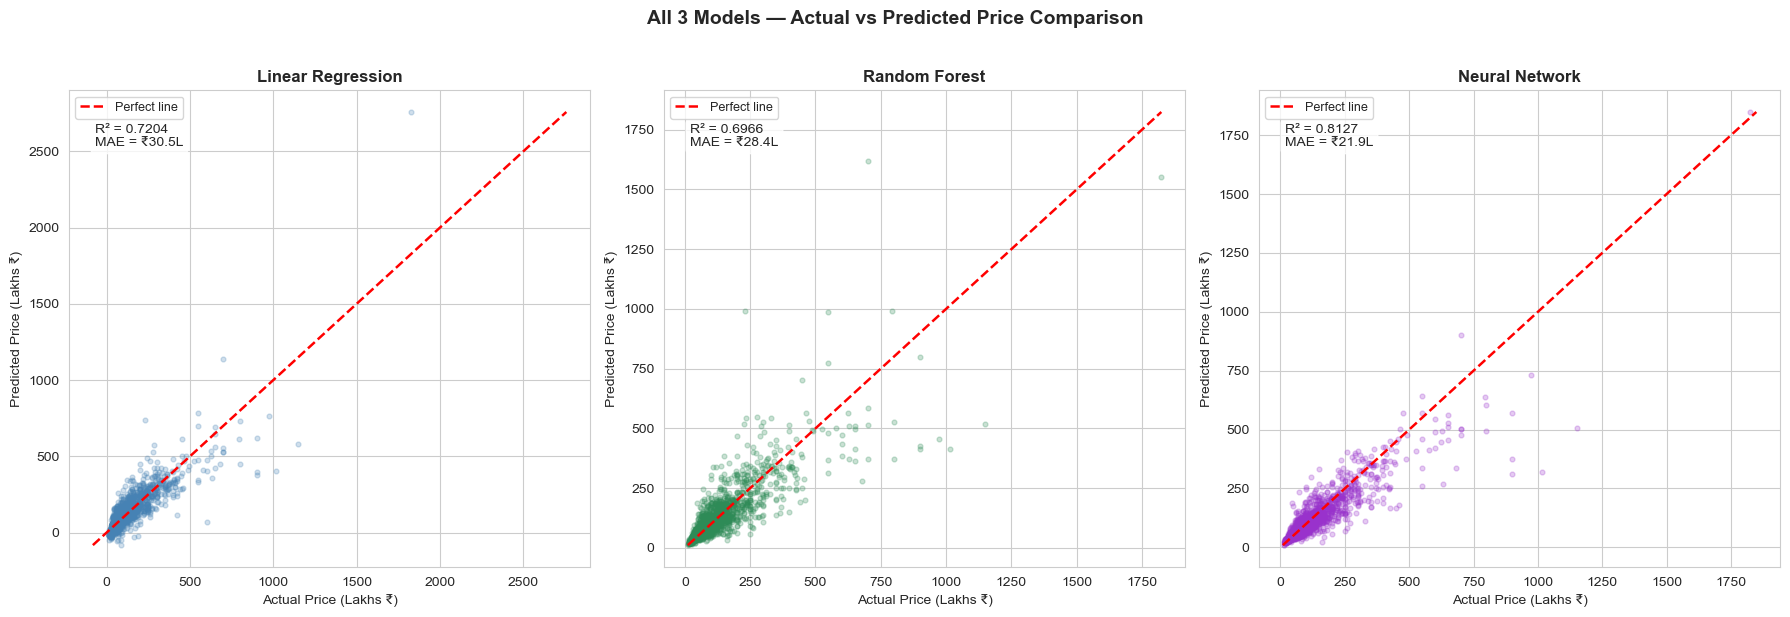

In [96]:
# Actual V Predicted Chart

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

models_info = [
    ("Linear Regression", y_pred_lr, "steelblue",  r2_score(y_test, y_pred_lr)),
    ("Random Forest",     y_pred_rf, "seagreen",   r2_score(y_test, y_pred_rf)),
    ("Neural Network",    y_pred_nn, "darkorchid", r2_score(y_test, y_pred_nn))
]

for ax, (name, y_pred, color, r2) in zip(axes, models_info):

    ax.scatter(y_test, y_pred, alpha=0.25, color=color, s=12)

    # Perfect prediction diagonal line
    min_val = min(y_test.min(), y_pred.min())
    max_val = max(y_test.max(), y_pred.max())
    ax.plot([min_val, max_val], [min_val, max_val],
            'r--', linewidth=1.8, label='Perfect line')

    # Show MAE and R² on chart
    mae = mean_absolute_error(y_test, y_pred)
    ax.text(0.05, 0.93,
            f'R² = {r2:.4f}\nMAE = ₹{mae:.1f}L',
            transform=ax.transAxes, fontsize=10,
            verticalalignment='top',
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

    ax.set_title(f'{name}', fontsize=12, fontweight='bold')
    ax.set_xlabel('Actual Price (Lakhs ₹)', fontsize=10)
    ax.set_ylabel('Predicted Price (Lakhs ₹)', fontsize=10)
    ax.legend(fontsize=9)

plt.suptitle('All 3 Models — Actual vs Predicted Price Comparison',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('C:/Users/Asus/Desktop/Vineet Data/Project/House Price Prediction/final_comparison.png', dpi=150)
plt.show()


In [97]:
# Building Predict function

def predict_house_price(area_type, location, total_sqft,
                        bath, balcony, bhk):
    
    input_data = pd.DataFrame({
        'total_sqft': [total_sqft],
        'bath'      : [bath],
        'balcony'   : [balcony],
        'bhk'       : [bhk],
        'area_type' : [area_type],
        'location'  : [location]
    })

    input_processed = preprocessor.transform(input_data)

    predicted_price = best_model.predict(
        input_processed, verbose=0
    )[0][0]
    
    return round(float(predicted_price), 2)

In [99]:
# Testing the prdict function

print("=" * 60)
print("HOUSE PRICE PREDICTIONS — BANGALORE")
print("=" * 60)

# List of test houses
test_houses = [
    {
        "area_type" : "Super built-up  Area",
        "location"  : "Whitefield",
        "total_sqft": 1200,
        "bath"      : 2,
        "balcony"   : 1,
        "bhk"       : 2,
        "description": "2 BHK Whitefield (1200 sqft)"
    },
    {
        "area_type" : "Super built-up  Area",
        "location"  : "Koramangala",
        "total_sqft": 1800,
        "bath"      : 3,
        "balcony"   : 2,
        "bhk"       : 3,
        "description": "3 BHK Koramangala (1800 sqft)"
    },
    {
        "area_type" : "Built-up  Area",
        "location"  : "Electronic City",
        "total_sqft": 900,
        "bath"      : 1,
        "balcony"   : 1,
        "bhk"       : 1,
        "description": "1 BHK Electronic City (900 sqft)"
    },
    {
        "area_type" : "Super built-up  Area",
        "location"  : "Indiranagar",
        "total_sqft": 2400,
        "bath"      : 4,
        "balcony"   : 2,
        "bhk"       : 4,
        "description": "4 BHK Indiranagar (2400 sqft)"
    },
    {
        "area_type" : "Plot  Area",
        "location"  : "Sarjapur  Road",
        "total_sqft": 3000,
        "bath"      : 4,
        "balcony"   : 3,
        "bhk"       : 4,
        "description": "4 BHK Plot Sarjapur Road (3000 sqft)"
    }
]

# Running predictions
for house in test_houses:
    price = predict_house_price(
        house['area_type'], house['location'],
        house['total_sqft'], house['bath'],
        house['balcony'],    house['bhk']
    )
    print(f"{house['description']:<40} → ₹{price} Lakhs")

print("=" * 60)

HOUSE PRICE PREDICTIONS — BANGALORE
2 BHK Whitefield (1200 sqft)             → ₹67.01 Lakhs
3 BHK Koramangala (1800 sqft)            → ₹145.24 Lakhs
1 BHK Electronic City (900 sqft)         → ₹33.25 Lakhs
4 BHK Indiranagar (2400 sqft)            → ₹147.58 Lakhs
4 BHK Plot Sarjapur Road (3000 sqft)     → ₹321.53 Lakhs


In [100]:
# Exporting data to CSV

split_df = pd.read_sql(
    "SELECT * FROM houses_split WHERE split = 'test'",
    con=engine
)

# Add all 3 model predictions
split_df['pred_linear_regression'] = np.round(y_pred_lr, 2)
split_df['pred_random_forest'] = np.round(y_pred_rf, 2)
split_df['pred_neural_network'] = np.round(y_pred_nn, 2)

# Add error columns for each model
split_df['error_lr'] = (split_df['pred_linear_regression']
                        - split_df['price']).round(2)
split_df['error_rf'] = (split_df['pred_random_forest']
                        - split_df['price']).round(2)
split_df['error_nn'] = (split_df['pred_neural_network']
                        - split_df['price']).round(2)

# Add absolute error columns
split_df['abs_error_lr'] = split_df['error_lr'].abs()
split_df['abs_error_rf'] = split_df['error_rf'].abs()
split_df['abs_error_nn'] = split_df['error_nn'].abs()

# Add price bucket column
def price_bucket(price):
    if   price <= 50:  return '₹0-50L'
    elif price <= 100: return '₹50-100L'
    elif price <= 200: return '₹100-200L'
    elif price <= 400: return '₹200-400L'
    else:              return '₹400L+'

split_df['price_bucket'] = split_df['price'].apply(price_bucket)

# Save to CSV
split_df.to_csv('C:/Users/Asus/Desktop/Vineet Data/Project/House Price Prediction/model_predictions.csv', index=False)

print("Predictions exported to model_predictions.csv")
print(f"Total rows: {len(split_df)}")
print(f"Total columns: {len(split_df.columns)}")
print()
print("Columns in the file:")
print(split_df.columns.tolist())

Predictions exported to model_predictions.csv
Total rows: 2599
Total columns: 18

Columns in the file:
['total_sqft', 'bath', 'balcony', 'bhk', 'area_type', 'location', 'price', 'split', 'pred_linear_regression', 'pred_random_forest', 'pred_neural_network', 'error_lr', 'error_rf', 'error_nn', 'abs_error_lr', 'abs_error_rf', 'abs_error_nn', 'price_bucket']


In [101]:
# Saving the model

split_df.to_sql('model_predictions', con=engine,
                if_exists='replace', index=False)

print("Saved to MySQL table: model_predictions")

# Also saving final model comparison
final_df['model_used'] = final_df['Model'].apply(
    lambda x: 'Linear Regression' if x == 'Linear Regression'
              else 'Random Forest'  if x == 'Random Forest'
              else 'Neural Network'
)
final_df.to_sql('model_results', con=engine,
                if_exists='replace', index=False)

print("Saved to MySQL table: model_results")

engine.dispose()
print()
print("MySQL connection closed!")
print()

Saved to MySQL table: model_predictions
Saved to MySQL table: model_results

MySQL connection closed!

